# Films_EDA_Kinopoisk_And_Imdb
Анализ фильмов и сериалов с kinopoisk и imdb

## Импорт библиотек

In [ ]:
!pip install pymorphy3

In [ ]:
import re
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import pymorphy3
from collections import Counter
from bs4 import BeautifulSoup
from pprint import pprint
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Загрузка данных

In [ ]:
dtype_dict = {
    "Title": "string",
    "kinopoiskId": "int",
    "imdbId": "string",
    "Year": "Int64",
    "ratingKinopoisk": "float",
    "ratingImdb": "float",
    "Age Limit": "string",
    "Genres": "string",
    "Country": "string",
    "Director": "string",
    "Description Kinopoisk": "string",
    "Description Imdb": "string"
}

In [ ]:
df = pd.read_csv("/content/data_films.csv", dtype=dtype_dict)
df_imdb = pd.read_csv("/content/imdb_films.csv")

## Первичная обработка

1. Title – название фильма (строка).

2. kinopoiskId – уникальный идентификатор фильма на сайте Кинопоиск (целое число или строка).

3. imdbId – уникальный идентификатор фильма на сайте IMDb (строка).

4. Year – год выпуска фильма (целое число).

5. Rating Kinopoisk – рейтинг фильма по версии Кинопоиска (дробное число от 0 до
10).

6. Rating Imdb – рейтинг фильма по версии IMDb (дробное число от 0 до 10).

7. Age Limit – возрастное ограничение фильма (например, "6+", "12+", "18+" и т. п.).

8. Genres – жанры фильма (строка или список жанров, разделённых запятой).

9. Country – страна или страны производства фильма (строка).

10. Director – имя режиссёра (строка).

11. Budget $ – бюджет фильма в долларах США (целое число).

12. Fees $ – кассовые сборы фильма в долларах США (целое число).

13. Description Kinopoisk – краткое описание фильма с сайта Кинопоиск на русском языке (строка).

14. Description Imdb – краткое описание фильма с сайта IMDb на английском языке (строка).



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477 entries, 0 to 476
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Title                  477 non-null    string 
 1   kinopoiskId            477 non-null    int64  
 2   imdbId                 477 non-null    string 
 3   Year                   476 non-null    Int64  
 4   Rating Kinopoisk       471 non-null    float64
 5   Rating Imdb            473 non-null    float64
 6   Age Limit              454 non-null    string 
 7   Genres                 477 non-null    string 
 8   Country                477 non-null    string 
 9   Director               475 non-null    string 
 10  Budget $               477 non-null    float64
 11  Fees $                 477 non-null    float64
 12  Description Kinopoisk  477 non-null    string 
 13  Description Imdb       473 non-null    string 
dtypes: Int64(1), float64(4), int64(1), string(8)
memory usage:

In [ ]:
df.head()

,Title,kinopoiskId,imdbId,Year,Rating Kinopoisk,Rating Imdb,Age Limit,Genres,Country,Director,Budget $,Fees $,Description Kinopoisk,Description Imdb
0,Реальная любовь,6144,tt0314331,2003,8.0,7.5,18+,"драма, мелодрама, комедия","США, Франция, Великобритания",Richard Curtis,40000000.0,250779876.0,Любовь поистине правит всеми вокруг — от премь...,Follows the lives of eight very different coup...
1,Заклятие,468994,tt1457767,2013,7.3,7.5,18+,"детектив, ужасы",США,James Wan,20000000.0,320422209.0,"Эд и Лоррейн Уоррены — детективы, которые расс...",Paranormal investigators Ed and Lorraine Warre...
2,Чудо,722951,tt2543472,2017,8.2,7.9,12+,"драма, семейный","США, Гонконг, Канада",Stephen Chbosky,20000000.0,315025930.0,С одной стороны 10-летний Август Пулман такой ...,"Based on the New York Times bestseller, this m..."
3,Такси,14349,tt0152930,1998,8.0,7.0,18+,"криминал, боевик, комедия",Франция,Gérard Pirès,53000000.0,0.0,Таксист Даниэль помешан на быстрой езде. Как у...,"To work off his tarnished driving record, a hi..."
4,Диспетчер,5435407,tt11539996,2024,7.2,7.0,18+,"триллер, боевик",США,David Mackenzie,0.0,4247491.0,"Брокер, занимающийся выгодными сделками между ...",A broker of lucrative payoffs between corrupt ...


### Приведение к нижнему регистру

In [ ]:
df["Genres"] = df["Genres"].str.lower()
df["Country"] = df["Country"].str.lower()
df["Description Kinopoisk"] = df["Description Kinopoisk"].str.lower()
df["Description Imdb"] = df["Description Imdb"].str.lower()

In [ ]:
df.head()

,Title,kinopoiskId,imdbId,Year,Rating Kinopoisk,Rating Imdb,Age Limit,Genres,Country,Director,Budget $,Fees $,Description Kinopoisk,Description Imdb
0,Реальная любовь,6144,tt0314331,2003,8.0,7.5,18+,"драма, мелодрама, комедия","сша, франция, великобритания",Richard Curtis,40000000.0,250779876.0,любовь поистине правит всеми вокруг — от премь...,follows the lives of eight very different coup...
1,Заклятие,468994,tt1457767,2013,7.3,7.5,18+,"детектив, ужасы",сша,James Wan,20000000.0,320422209.0,"эд и лоррейн уоррены — детективы, которые расс...",paranormal investigators ed and lorraine warre...
2,Чудо,722951,tt2543472,2017,8.2,7.9,12+,"драма, семейный","сша, гонконг, канада",Stephen Chbosky,20000000.0,315025930.0,с одной стороны 10-летний август пулман такой ...,"based on the new york times bestseller, this m..."
3,Такси,14349,tt0152930,1998,8.0,7.0,18+,"криминал, боевик, комедия",франция,Gérard Pirès,53000000.0,0.0,таксист даниэль помешан на быстрой езде. как у...,"to work off his tarnished driving record, a hi..."
4,Диспетчер,5435407,tt11539996,2024,7.2,7.0,18+,"триллер, боевик",сша,David Mackenzie,0.0,4247491.0,"брокер, занимающийся выгодными сделками между ...",a broker of lucrative payoffs between corrupt ...


### Обработка возраста

In [ ]:
def clean_age(age):
    try:
        return int(age.strip().replace('+', ''))
    except:
        return np.nan

df["Age Limit"] = df["Age Limit"].apply(clean_age)

### Обработка бюджета и сборов

In [ ]:
df[["Budget $", "Fees $"]] = df[["Budget $", "Fees $"]].replace(0, np.nan)

In [ ]:
df = df.rename(columns={
    "Budget $": "Budget",
    "Fees $": "Fees"
})

In [ ]:
df.head()

,Title,kinopoiskId,imdbId,Year,Rating Kinopoisk,Rating Imdb,Age Limit,Genres,Country,Director,Budget,Fees,Description Kinopoisk,Description Imdb
0,Реальная любовь,6144,tt0314331,2003,8.0,7.5,18.0,"драма, мелодрама, комедия","сша, франция, великобритания",Richard Curtis,40000000.0,250779876.0,любовь поистине правит всеми вокруг — от премь...,follows the lives of eight very different coup...
1,Заклятие,468994,tt1457767,2013,7.3,7.5,18.0,"детектив, ужасы",сша,James Wan,20000000.0,320422209.0,"эд и лоррейн уоррены — детективы, которые расс...",paranormal investigators ed and lorraine warre...
2,Чудо,722951,tt2543472,2017,8.2,7.9,12.0,"драма, семейный","сша, гонконг, канада",Stephen Chbosky,20000000.0,315025930.0,с одной стороны 10-летний август пулман такой ...,"based on the new york times bestseller, this m..."
3,Такси,14349,tt0152930,1998,8.0,7.0,18.0,"криминал, боевик, комедия",франция,Gérard Pirès,53000000.0,NaN,таксист даниэль помешан на быстрой езде. как у...,"to work off his tarnished driving record, a hi..."
4,Диспетчер,5435407,tt11539996,2024,7.2,7.0,18.0,"триллер, боевик",сша,David Mackenzie,NaN,4247491.0,"брокер, занимающийся выгодными сделками между ...",a broker of lucrative payoffs between corrupt ...


### Пропущенные значения

In [ ]:
df.isna().sum()

,0
Title,0
kinopoiskId,0
imdbId,0
Year,1
Rating Kinopoisk,6
Rating Imdb,4
Age Limit,23
Genres,0
Country,0
Director,2


### Уменьшение пропусков

In [ ]:
df_merged = df.merge(df_imdb, on="Title", how="left", suffixes=('', '_imdb'))

In [ ]:
df_merged.head()

,Title,kinopoiskId,imdbId,Year,Rating Kinopoisk,Rating Imdb,Age Limit,Genres,Country,Director,...,Description Imdb,Year_imdb,Rating,Age Limit_imdb,Genres_imdb,Country_imdb,Director_imdb,Budget_imdb,Fees_imdb,Description
0,Реальная любовь,6144,tt0314331,2003,8.0,7.5,18.0,"драма, мелодрама, комедия","сша, франция, великобритания",Richard Curtis,...,follows the lives of eight very different coup...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Заклятие,468994,tt1457767,2013,7.3,7.5,18.0,"детектив, ужасы",сша,James Wan,...,paranormal investigators ed and lorraine warre...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Чудо,722951,tt2543472,2017,8.2,7.9,12.0,"драма, семейный","сша, гонконг, канада",Stephen Chbosky,...,"based on the new york times bestseller, this m...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Такси,14349,tt0152930,1998,8.0,7.0,18.0,"криминал, боевик, комедия",франция,Gérard Pirès,...,"to work off his tarnished driving record, a hi...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Диспетчер,5435407,tt11539996,2024,7.2,7.0,18.0,"триллер, боевик",сша,David Mackenzie,...,a broker of lucrative payoffs between corrupt ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_merged.isna().sum()

,0
Title,0
kinopoiskId,0
imdbId,0
Year,1
Rating Kinopoisk,6
Rating Imdb,4
Age Limit,23
Genres,0
Country,0
Director,2


### Берём пропущенные значения из imbd_films.csv

In [ ]:
columns_to_fill = {
    'Rating Imdb': 'Rating',
    'Age Limit': 'Age Limit_imdb',
    'Director': 'Director_imdb',
    'Description Imdb': 'Description',
}

for col_main, col_imdb in columns_to_fill.items():
    df_merged[col_main] = df_merged[col_main].combine_first(df_merged[col_imdb])
    df_merged.drop(columns=[col_imdb], inplace=True)

In [ ]:
df_merged.isna().sum()

,0
Title,0
kinopoiskId,0
imdbId,0
Year,1
Rating Kinopoisk,6
Rating Imdb,4
Age Limit,21
Genres,0
Country,0
Director,2


In [ ]:
# Удаляем все столбцы, которые заканчиваются на '_imdb'
cols_to_drop = [col for col in df_merged.columns if col.endswith('_imdb')]
df_merged = df_merged.drop(columns=cols_to_drop)

# Проверяем итоговые столбцы и пропуски
df_merged.isna().sum()

,0
Title,0
kinopoiskId,0
imdbId,0
Year,1
Rating Kinopoisk,6
Rating Imdb,4
Age Limit,21
Genres,0
Country,0
Director,2


Стало на 2 пропуска меньше в возрастном ограничении

In [ ]:
df_merged = df_merged.rename(columns={
    'kinopoiskId': 'kinopoisk_id',
    'imdbId': 'imdb_id'
})

In [ ]:
df = df_merged

In [ ]:
df.head()

,Title,kinopoisk_id,imdb_id,Year,Rating Kinopoisk,Rating Imdb,Age Limit,Genres,Country,Director,Budget,Fees,Description Kinopoisk,Description Imdb
0,Реальная любовь,6144,tt0314331,2003,8.0,7.5,18.0,"драма, мелодрама, комедия","сша, франция, великобритания",Richard Curtis,40000000.0,250779876.0,любовь поистине правит всеми вокруг — от премь...,follows the lives of eight very different coup...
1,Заклятие,468994,tt1457767,2013,7.3,7.5,18.0,"детектив, ужасы",сша,James Wan,20000000.0,320422209.0,"эд и лоррейн уоррены — детективы, которые расс...",paranormal investigators ed and lorraine warre...
2,Чудо,722951,tt2543472,2017,8.2,7.9,12.0,"драма, семейный","сша, гонконг, канада",Stephen Chbosky,20000000.0,315025930.0,с одной стороны 10-летний август пулман такой ...,"based on the new york times bestseller, this m..."
3,Такси,14349,tt0152930,1998,8.0,7.0,18.0,"криминал, боевик, комедия",франция,Gérard Pirès,53000000.0,NaN,таксист даниэль помешан на быстрой езде. как у...,"to work off his tarnished driving record, a hi..."
4,Диспетчер,5435407,tt11539996,2024,7.2,7.0,18.0,"триллер, боевик",сша,David Mackenzie,NaN,4247491.0,"брокер, занимающийся выгодными сделками между ...",a broker of lucrative payoffs between corrupt ...


### Итог

In [ ]:
df.shape

(477, 14)

In [ ]:
df.isna().sum()

,0
Title,0
kinopoisk_id,0
imdb_id,0
Year,1
Rating Kinopoisk,6
Rating Imdb,4
Age Limit,21
Genres,0
Country,0
Director,2


## Визуализация датасета

### Облако слов для imdb

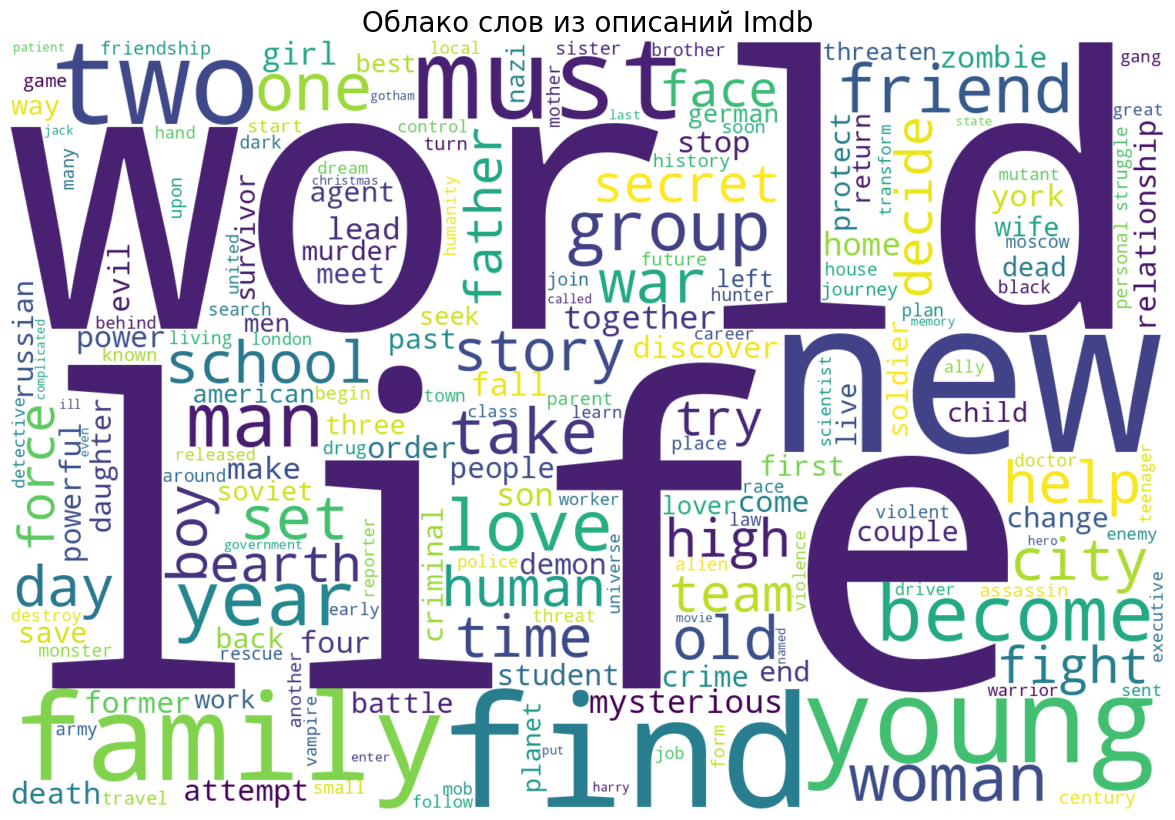

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

text = ' '.join(df['Description Imdb'].dropna().values)
text = re.sub(r'[^a-zA-Z]', ' ', text)

tokens = nltk.word_tokenize(text.lower())
lem_tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words and len(token) > 2]

wordcloud = WordCloud(width=1500, height=1000, background_color='white', random_state=42, collocations=False)
wordcloud.generate(' '.join(lem_tokens))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов из описаний Imdb', fontsize=20)
plt.show()

На IMDb чаще всего встречаются описания фильмов о жизни, семье, отношениях. Это показывает, что зрителям особенно интересны истории о личностном росте, обществе и моральном выборе.

In [ ]:
word_counts = Counter(lem_tokens)
print(word_counts.most_common(20))

[('life', 73), ('world', 56), ('new', 53), ('find', 53), ('family', 45), ('young', 44), ('two', 43), ('must', 41), ('year', 40), ('man', 40), ('love', 34), ('group', 32), ('woman', 30), ('one', 29), ('friend', 29), ('take', 26), ('set', 25), ('war', 25), ('old', 24), ('becomes', 24)]


### Облако слов для kinopoisk

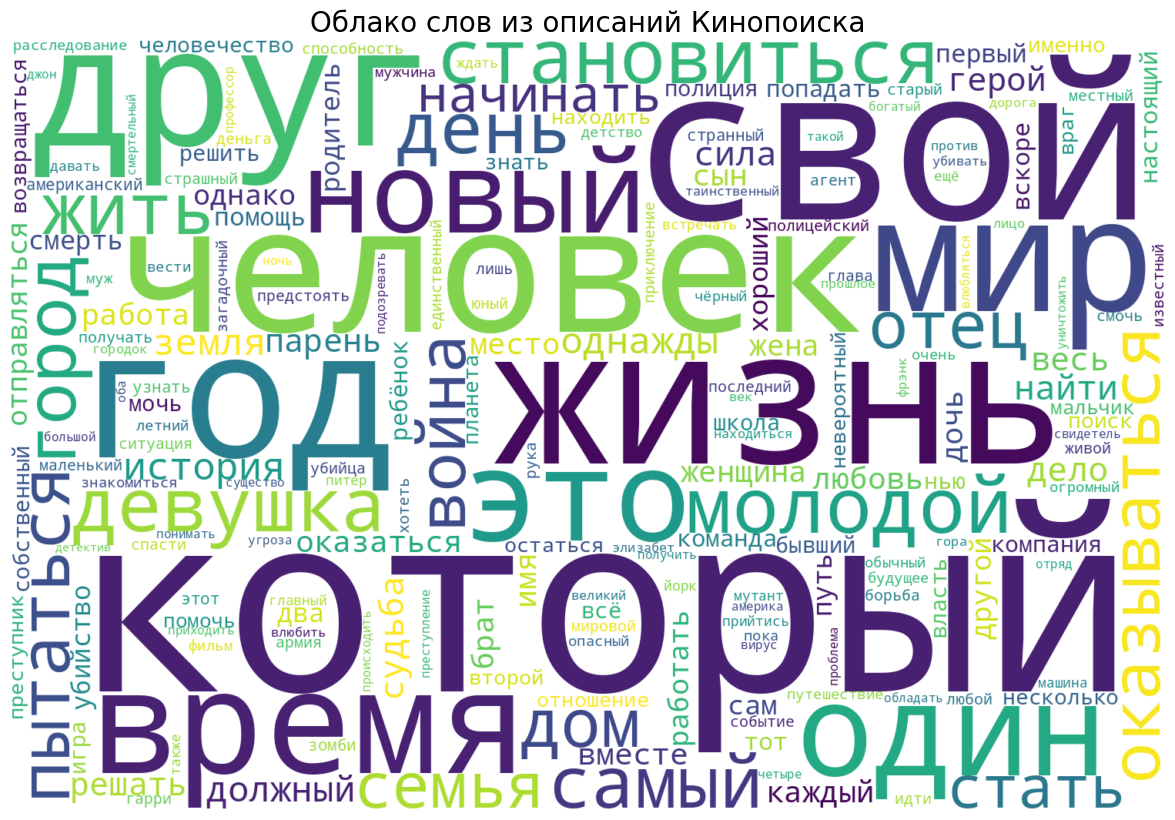

In [ ]:
morph = pymorphy3.MorphAnalyzer()
stop_words_ru = set(stopwords.words('russian'))

text_ru = ' '.join(df['Description Kinopoisk'].dropna().values)
text_ru = re.sub(r'[^а-яА-ЯёЁ]', ' ', text_ru)

tokens_ru = nltk.word_tokenize(text_ru.lower())

lemmatized_tokens = [
    morph.parse(token)[0].normal_form
    for token in tokens_ru
    if token not in stop_words_ru and len(token) > 2
]

wordcloud = WordCloud(width=1500,
                      height=1000,
                      background_color='white',
                      random_state=42,
                      collocations=False
).generate(' '.join(lemmatized_tokens))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов из описаний Кинопоиска', fontsize=20)
plt.show()

В описаниях фильмов на Кинопоиске наиболее часто встречаются слова, связанные с человеком, жизнью, временем, друзьями и переменами. Это отражает ориентацию сюжетов на личные истории, отношения и события, меняющие судьбу героев.

### Облако слов для режиссёров

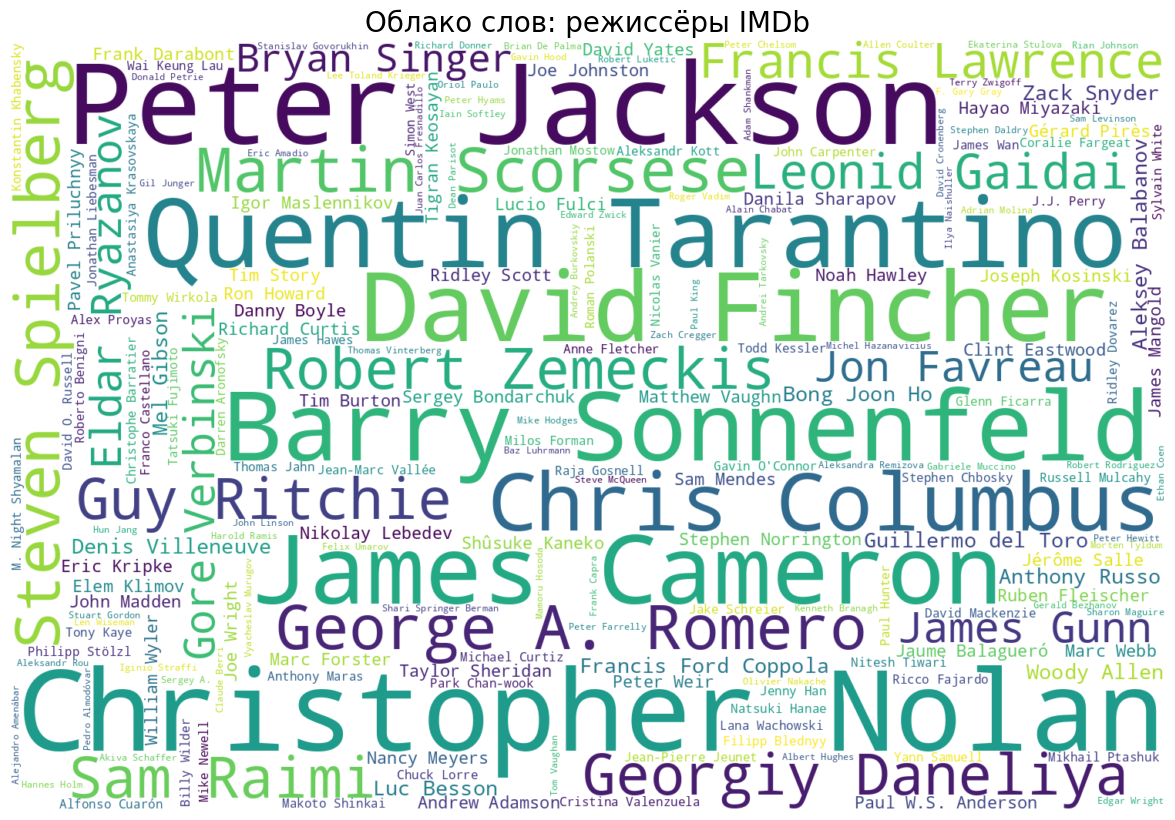

In [ ]:
directors = df['Director'].dropna().astype(str)
directors = [name.strip() for name in directors]
counter = Counter(directors)

wordcloud = WordCloud(
    width=1500, height=1000,
    background_color='white',
    random_state=42
).generate_from_frequencies(counter)

plt.figure(figsize=(17, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: режиссёры IMDb', fontsize=20)
plt.show()

In [ ]:
counter.most_common(10)

[('Christopher Nolan', 7),
 ('Peter Jackson', 7),
 ('James Cameron', 5),
 ('Barry Sonnenfeld', 5),
 ('Quentin Tarantino', 5),
 ('David Fincher', 5),
 ('Chris Columbus', 5),
 ('George A. Romero', 4),
 ('Steven Spielberg', 4),
 ('Martin Scorsese', 4)]

Самые популярные режиссёры. Наибольшее внимание получают такие имена, как Кристофер Нолан, Питер Джексон, Дэвид Финчер, Квентин Тарантино и Стивен Спилберг, что подчёркивает их значимость и известность в современной кинематографии.

### Облако слов для жанров

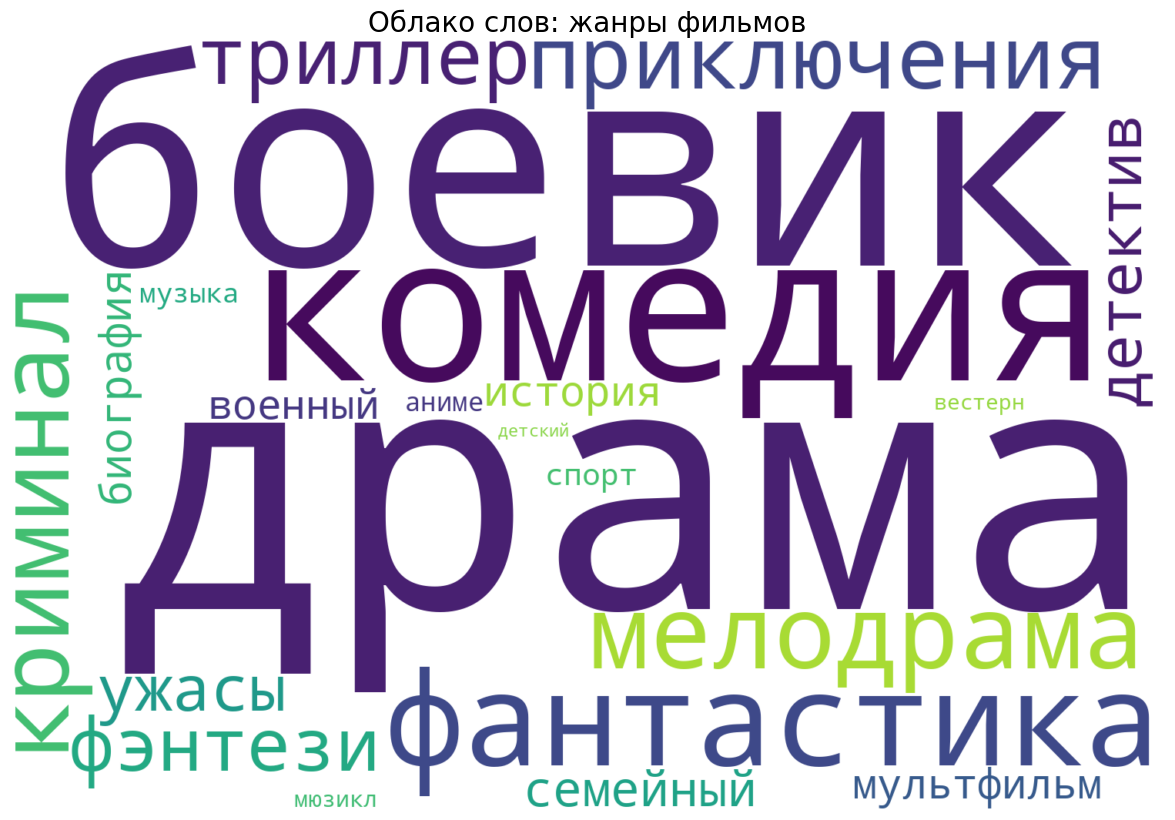

In [ ]:
genres = df['Genres'].dropna().astype(str)

all_genres = []
for g in genres:
    all_genres.extend([genre.strip() for genre in g.split(',')])

genre_counts = Counter(all_genres)

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42
).generate_from_frequencies(genre_counts)

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: жанры фильмов', fontsize=20)
plt.show()


In [ ]:
genre_counts

Counter({'драма': 250,
         'мелодрама': 109,
         'комедия': 154,
         'детектив': 54,
         'ужасы': 59,
         'семейный': 32,
         'криминал': 101,
         'боевик': 164,
         'триллер': 97,
         'военный': 22,
         'история': 24,
         'фантастика': 115,
         'вестерн': 5,
         'биография': 26,
         'фэнтези': 83,
         'приключения': 101,
         'спорт': 11,
         'мультфильм': 23,
         'детский': 3,
         'аниме': 8,
         'музыка': 9,
         'мюзикл': 6})

Самые популярные жанры это: "Драма", "Боевик" и "Комедия"

### Облака слов описаний для жанра "Драма"

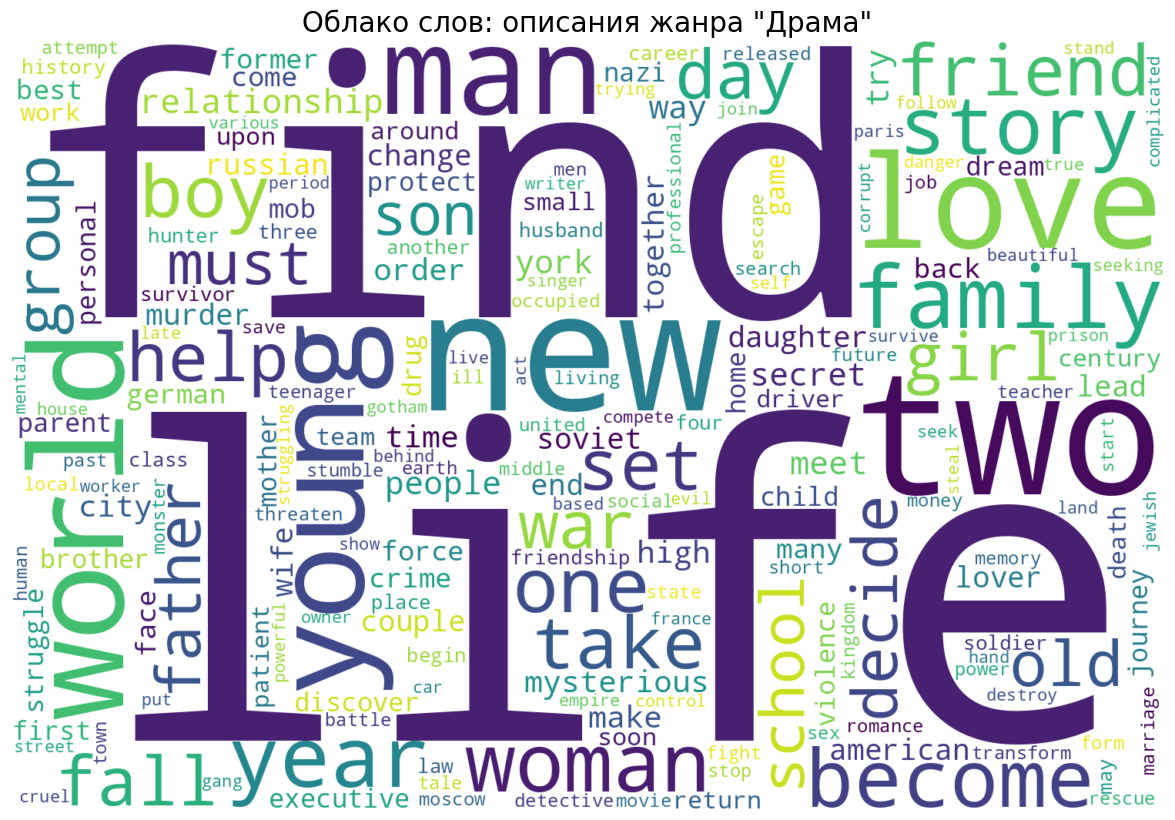

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))

df_drama_imdb = df[df['Genres'].str.contains('Драма', case=False, na=False)]

text_drama_imdb = ' '.join(df_drama_imdb['Description Imdb'].dropna().values)

text_drama_imdb = re.sub(r'[^a-zA-Z]', ' ', text_drama_imdb)

tokens_drama_en = nltk.word_tokenize(text_drama_imdb.lower())

lemmatized_tokens_en = [
    lemmatizer.lemmatize(token)
    for token in tokens_drama_en
    if token not in stop_words_en and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens_en))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания жанра "Драма"', fontsize=20)
plt.show()


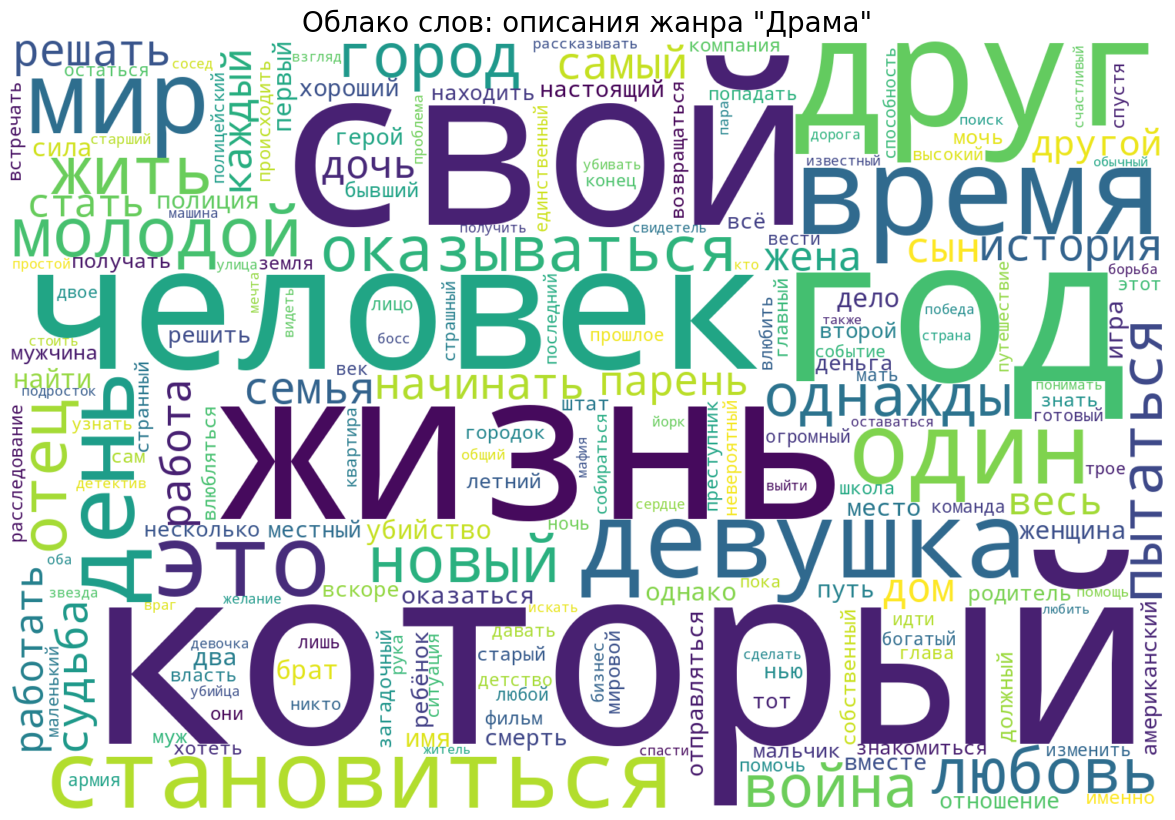

In [ ]:
morph = pymorphy3.MorphAnalyzer()
stop_words_ru = set(stopwords.words('russian'))

df_drama = df[df['Genres'].str.contains('драма', case=False, na=False)]

text_drama = ' '.join(df_drama['Description Kinopoisk'].dropna().values)

text_drama = re.sub(r'[^а-яА-ЯёЁ]', ' ', text_drama)

tokens_drama = nltk.word_tokenize(text_drama.lower())

lemmatized_tokens = [
    morph.parse(token)[0].normal_form
    for token in tokens_drama
    if token not in stop_words_ru and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания жанра "Драма"', fontsize=20)
plt.show()


В описаниях жанра "драма" наибольшую частоту имеют слова, связанные с жизнью, человеческими отношениями, выбором и поисками смысла. Акцент делается на судьбе, любви, семье и процессе личных изменений.



### Облака слов описаний для жанра "Боевик"

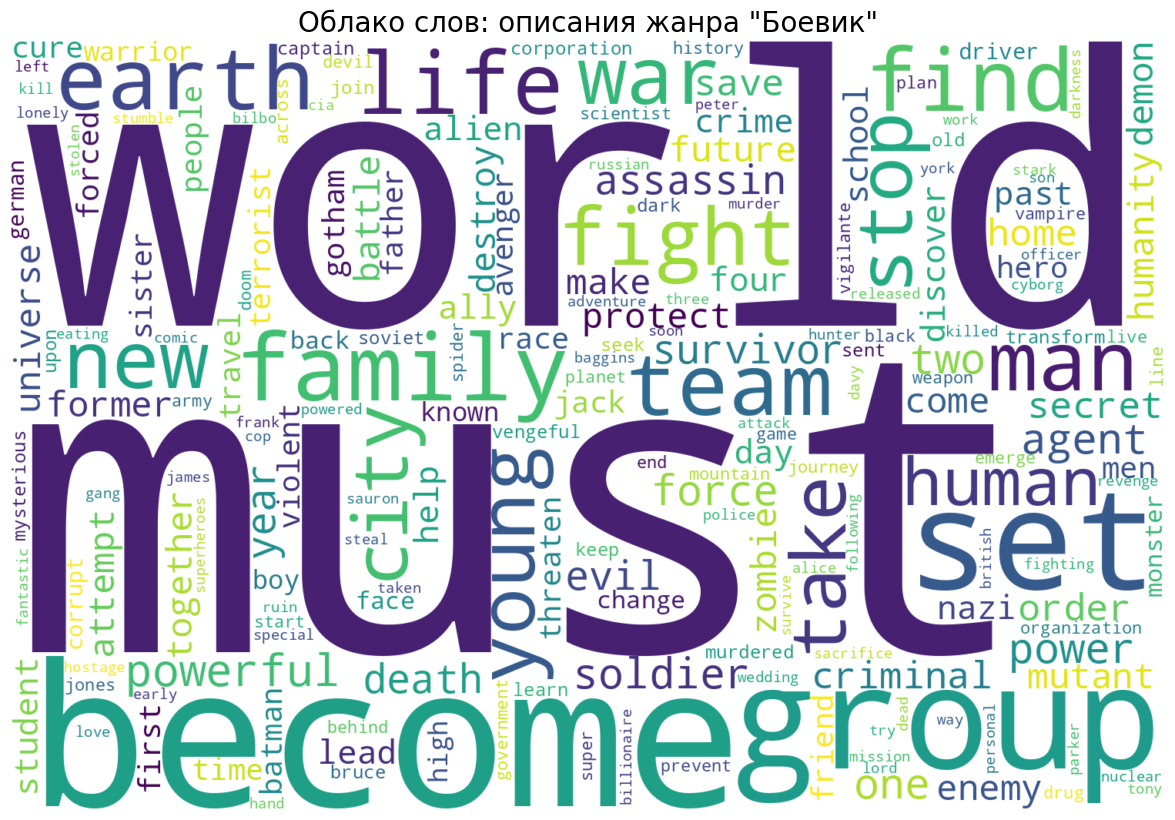

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))

df_boevik_imdb = df[df['Genres'].str.contains('Боевик', case=False, na=False)]

text_boevik_imdb = ' '.join(df_boevik_imdb['Description Imdb'].dropna().values)

text_boevik_imdb = re.sub(r'[^a-zA-Z]', ' ', text_boevik_imdb)

tokens_boevik_en = nltk.word_tokenize(text_boevik_imdb.lower())

lemmatized_tokens_en = [
    lemmatizer.lemmatize(token)
    for token in tokens_boevik_en
    if token not in stop_words_en and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens_en))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания жанра "Боевик"', fontsize=20)
plt.show()


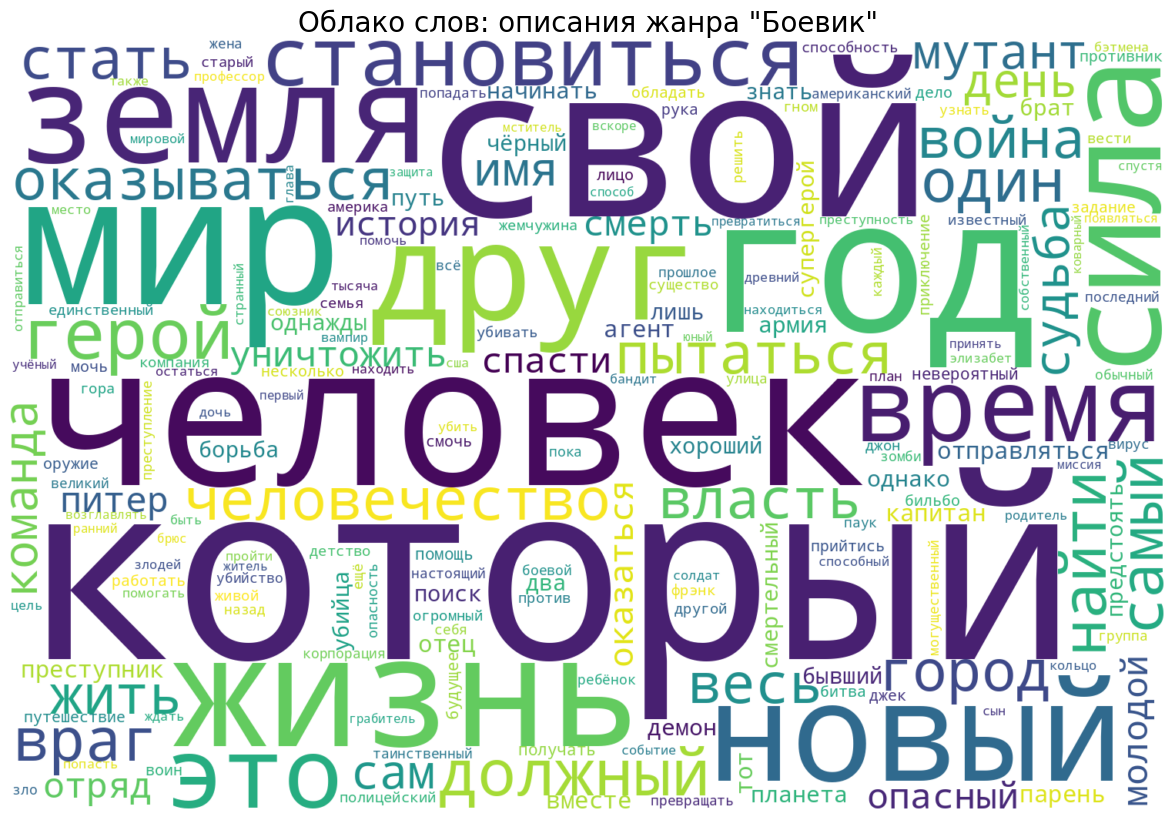

In [ ]:
morph = pymorphy3.MorphAnalyzer()
stop_words_ru = set(stopwords.words('russian'))

df_boevik = df[df['Genres'].str.contains('Боевик', case=False, na=False)]

text_boevik = ' '.join(df_boevik['Description Kinopoisk'].dropna().values)

text_boevik = re.sub(r'[^а-яА-ЯёЁ]', ' ', text_boevik)

tokens_boevik = nltk.word_tokenize(text_boevik.lower())

lemmatized_tokens = [
    morph.parse(token)[0].normal_form
    for token in tokens_boevik
    if token not in stop_words_ru and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания жанра "Боевик"', fontsize=20)
plt.show()


В описаниях жанра "боевик" преобладают слова, связанные с силой, спасением, противостоянием и войной. Часто встречаются темы героя, команды, человечества и опасности, отражая динамику и конфликтность этого жанра.

### Облака слов описаний для жанра "Комедия"

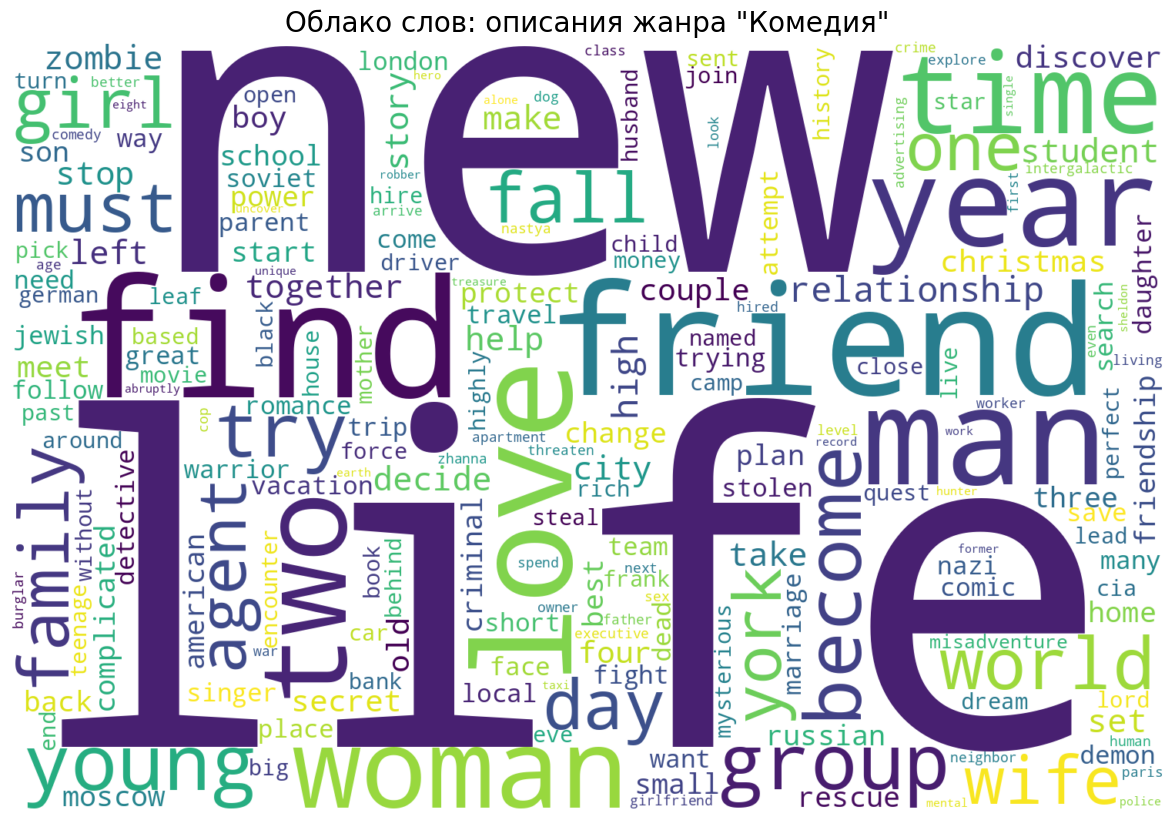

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))

df_comedy_imdb = df[df['Genres'].str.contains('Комедия', case=False, na=False)]

text_comedy_imdb = ' '.join(df_comedy_imdb['Description Imdb'].dropna().values)

text_comedy_imdb = re.sub(r'[^a-zA-Z]', ' ', text_comedy_imdb)

tokens_comedy_en = nltk.word_tokenize(text_comedy_imdb.lower())

lemmatized_tokens_en = [
    lemmatizer.lemmatize(token)
    for token in tokens_comedy_en
    if token not in stop_words_en and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens_en))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания жанра "Комедия"', fontsize=20)
plt.show()


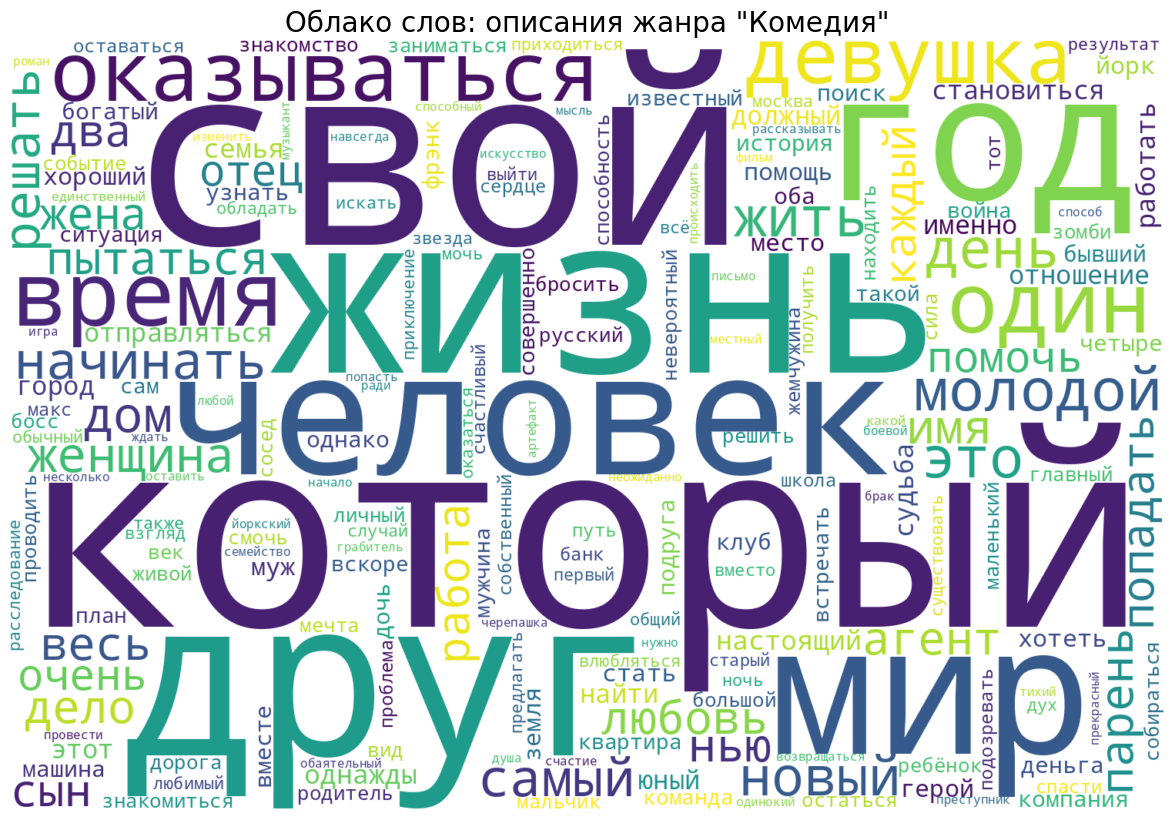

In [ ]:
morph = pymorphy3.MorphAnalyzer()
stop_words_ru = set(stopwords.words('russian'))

df_comedy= df[df['Genres'].str.contains('Комедия', case=False, na=False)]

text_comedy = ' '.join(df_comedy['Description Kinopoisk'].dropna().values)

text_comedy = re.sub(r'[^а-яА-ЯёЁ]', ' ', text_comedy)

tokens_comedy = nltk.word_tokenize(text_comedy.lower())

lemmatized_tokens = [
    morph.parse(token)[0].normal_form
    for token in tokens_comedy
    if token not in stop_words_ru and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания жанра "Комедия"', fontsize=20)
plt.show()


В описаниях жанра "комедия" преобладают слова, связанные с жизнью, друзьями, отношениями и поиском себя. В центре сюжетов часто оказываются человек, его окружение, смешные жизненные ситуации и личные перемены.

### Облака слов описаний для режиссёра - Кристофера Нолана

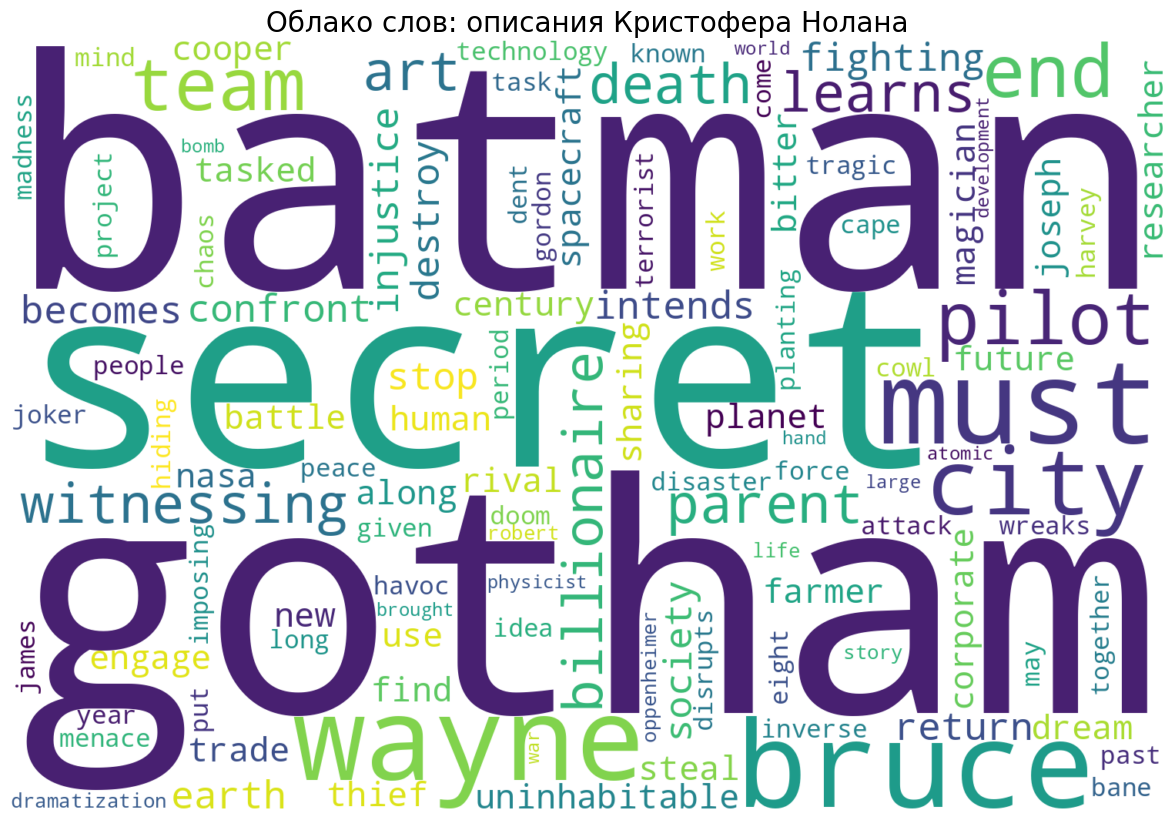

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words_en = set(stopwords.words('english'))
df_nolan = df[df['Director'] == "Christopher Nolan"]

text_nolan = ' '.join(df_nolan['Description Imdb'].dropna().values)

text_nolan = re.sub(r'[^a-zA-Z]', ' ', text_nolan)

tokens_nolan = nltk.word_tokenize(text_nolan.lower())

lemmatized_tokens_en = [
    lemmatizer.lemmatize(token)
    for token in tokens_nolan
    if token not in stop_words_en and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens_en))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания Кристофера Нолана', fontsize=20)
plt.show()


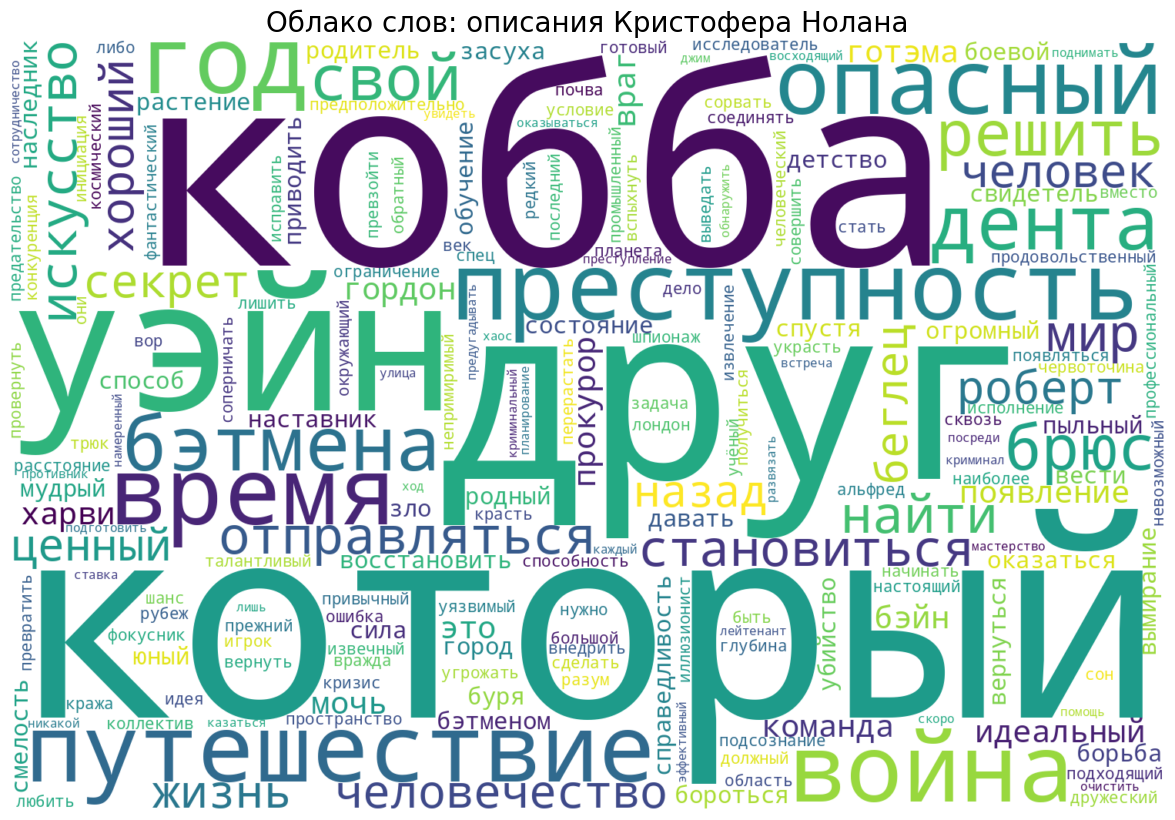

In [ ]:
morph = pymorphy3.MorphAnalyzer()
stop_words_ru = set(stopwords.words('russian'))

df_nolan = df[df['Director'] == "Christopher Nolan"]

text_nolan = ' '.join(df_nolan['Description Kinopoisk'].dropna().values)

text_nolan = re.sub(r'[^а-яА-ЯёЁ]', ' ', text_nolan)

tokens_nolan = nltk.word_tokenize(text_nolan.lower())

lemmatized_tokens = [
    morph.parse(token)[0].normal_form
    for token in tokens_nolan
    if token not in stop_words_ru and len(token) > 2
]

wordcloud = WordCloud(
    width=1500,
    height=1000,
    background_color='white',
    random_state=42,
    collocations=False
).generate(' '.join(lemmatized_tokens))

plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов: описания Кристофера Нолана', fontsize=20)
plt.show()


Чаще всего встречаются слова «Бэтмен», «Кобба», «Уэйн», «преступность», «время», «путешествие», «война», «опасный», «человечество». Это указывает на главные темы фильмов Нолана — сложные персонажи (Кобб из Начала, Брюс Уэйн/Бэтмен), противостояние преступности, мотив времени и путешествий, борьба за выживание и судьбу человечества.